<a href="https://colab.research.google.com/github/Firefox-097/Steganography/blob/main/Steganography_MobileNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d marcozuppelli/stegoimagesdataset
!unzip -q stegoimagesdataset.zip -d /content/stegoimages

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/marcozuppelli/stegoimagesdataset
License(s): DbCL-1.0
 52% 799M/1.51G [00:18<00:11, 67.4MB/s]

In [ ]:
import os

print(os.listdir("/content/stegoimages"))

In [ ]:
import os

folders = [
    "/content/stegoimages/train/train/clean",
    "/content/stegoimages/train/train/stego",
    "/content/stegoimages/val/val/clean",
    "/content/stegoimages/val/val/stego",
    "/content/stegoimages/test/test/clean",
    "/content/stegoimages/test/test/stego"
]

for folder in folders:
    print(folder, ":", len(os.listdir(folder)))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_directory(
    "/content/stegoimages/train/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    "/content/stegoimages/val/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 16000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


In [ ]:
print(train_gen.class_indices)
print("Training Images:", train_gen.samples)
print("Validation Images:", val_gen.samples)

{'clean': 0, 'stego': 1}
Training Images: 16000
Validation Images: 8000


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained backbone
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Total Parameters:", model.count_params())

Total Parameters: 2422081


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_stego_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_gen.classes

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(2.0), 1: np.float64(0.6666666666666666)}


In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    class_weight=class_weights
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4819 - loss: 0.7241
Epoch 1: val_accuracy improved from None to 0.25750, saving model to /content/drive/MyDrive/best_stego_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_stego_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 973s 2s/step - accuracy: 0.4657 - loss: 0.7045 - val_accuracy: 0.2575 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3547 - loss: 0.6934
Epoch 2: val_accuracy improved from 0.25750 to 0.74462, saving model to /content/drive/MyDrive/best_stego_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_stego_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 984s 2s/step - accuracy: 0.3803 - loss: 0.6935 - val_accuracy: 0.7446 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7355 - loss: 0.6858
Epoch 3: val_accuracy did not improve from 0.74462
500/500 ━━━━━━━

In [ ]:
print("Train Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])

Train Accuracy: 0.7386875152587891
Validation Accuracy: 0.7419999837875366


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    "/content/stegoimages/test/test",
    classes=["clean", "stego"],
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 8000 images belonging to 2 classes.


In [ ]:
pred = model.predict(test_gen)

250/250 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step


In [ ]:
import numpy as np
predictions = (pred > 0.5).astype(int).flatten()

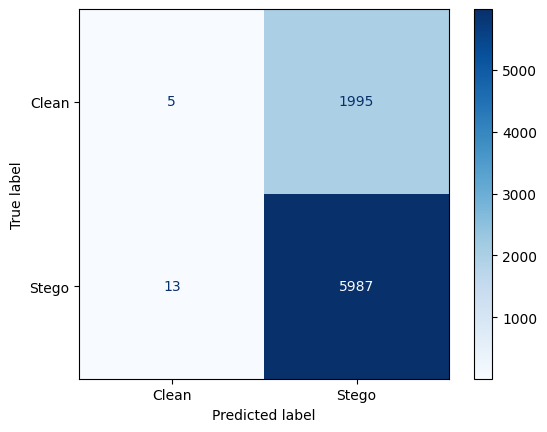

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(test_gen.classes, predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=["Clean","Stego"])
disp.plot(cmap="Blues")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_gen.classes,
    predictions,
    target_names=["Clean","Stego"]
))

              precision    recall  f1-score   support

       Clean       0.28      0.00      0.00      2000
       Stego       0.75      1.00      0.86      6000

    accuracy                           0.75      8000
   macro avg       0.51      0.50      0.43      8000
weighted avg       0.63      0.75      0.64      8000

